## Adversarial attemps to deviate the diffusion trajectory

This notebook is dedicated to testing different attacks on the DDIM process, in order to deviate the diffused trajectory of geographic coordinates.

2 possible justifications for this:
- Make Geogesser great again: the site wants to adversarially patch its images to avoid that players can use AI based tools to outperform others.
- Protect privacy: cf [Geoshield paper](https://arxiv.org/pdf/2508.03209v1)

In [18]:
from plonk.pipe import PlonkPipeline
from PIL import Image
import torch
import torch.nn.functional as F
import tqdm as tqdm
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import Normalize
device = torch.device("cuda")
from torchvision import transforms

#### Attempt 1: simplest atttack

We experiment the following attack
- craft a universal perturbation $c_p$, added to image $c$ in pixel space before a forward pass.
- The goal is to maximize the angle between $\epsilon$ and $\psi(x_t|c+\delta)$ at each step.
- We expect this to deviate the trajectory.

2 options are possible for training the attack:
- training just as we train a diffusion model, but change objective.
- training on the diffusion model's conditional sampling steps. 

First, we evaluate our attack on a single image $c_{src}$

The objective is : $$\delta_{encoder} = arg min_{||\delta||_{\infty}} \mathbb{E}_{x_0,\epsilon,t}[<\psi(x_t|c_{src}+\delta), \epsilon>^2]$$

The aim here is to target predicted perturbation directions $\psi(x_t|c_{src}+\delta)$ which are orthogonal to the true perturbation $\epsilon$, so as to derail the diffusion process from its normal course. The squarred dot product is used because we target a null dot product, and we want the loss function to be differentiable (absolute value would not be satisfactory).

We will experiment the minimization of the dot product (e.g. targetting $-\epsilon$) later.

The perturbation is trained via projected gradient descent (cf literature).

We start with an easy to localize image, e.g. the eiffel tower. This might be too hard.

First, we choose to train with uniform sampling steps.
We could later on choose to sample only $t$ corresponding to inference steps when estimating risk. 

In [ ]:
# Attempt 1 training pipeline: universal perturbation on a single source image
# Objective: min E_{x0, eps, t} <psi(x_t | c+delta), eps>^2
# where x_t = sqrt(gamma_t) * x0 + sqrt(1-gamma_t) * eps

from plonk.pipe import _gps_degrees_to_cartesian
# def gps_to_cartesian(gps_deg: np.ndarray, device=device) -> torch.Tensor:
#     """Convert [lat, lon] in degrees to 3D cartesian coordinates on the unit sphere."""
#     gps_deg = np.asarray(gps_deg)
#     if gps_deg.ndim == 1:
#         gps_deg = gps_deg[None, :]

#     lat = np.radians(gps_deg[:, 0])
#     lon = np.radians(gps_deg[:, 1])
#     x = np.cos(lat) * np.cos(lon)
#     y = np.cos(lat) * np.sin(lon)
#     z = np.sin(lat)
#     xyz = np.stack([x, y, z], axis=-1)
#     return torch.tensor(xyz, dtype=torch.float32, device=device)


def build_x0_bank_from_clean_model(
    pipeline,
    source_image,
    n_samples=256,
    num_steps=200,
    cfg=0.0,
):
    """
    Build a bank of plausible x0 states by sampling the clean model on the source image.
    This approximates expectation over x0 in the objective.
    """
    with torch.no_grad():
        gps_samples = pipeline(
            source_image,
            batch_size=n_samples,
            num_steps=num_steps,
            cfg=cfg,
        )
    return _gps_degrees_to_cartesian(gps_samples, device=device)


def train_universal_perturbation_attempt1(
    source_image,
    pipeline,
    n_steps=400,
    train_batch_size=64,
    lr=2e-2,
    eps_max=0.06,
    anchor_samples=256,
    clean_num_steps=200,
    log_every=20,
):
    # Freeze PLONK denoiser and embedding model parameters (we only optimize delta)
    pipeline.network.eval().requires_grad_(False)
    pipeline.cond_preprocessing.emb_model.eval().requires_grad_(False)

    # Preprocess once; perturbation is optimized in normalized-image space
    source_tensor = (
        pipeline.cond_preprocessing.augmentation(source_image)
        .unsqueeze(0)
        .to(device)
    )  # [1, 3, H, W]

    # Universal perturbation parameter
    delta = torch.zeros_like(source_tensor, requires_grad=True)
    optimizer = torch.optim.Adam([delta], lr=lr)

    # Approximate x0 distribution for this source image
    x0_bank = build_x0_bank_from_clean_model(
        pipeline,
        source_image,
        n_samples=anchor_samples,
        num_steps=clean_num_steps,
        cfg=0.0,
    )  # [N, 3]

    history = []
    pbar = tqdm.trange(n_steps, desc="PGD attack training")

    for step in pbar:
        optimizer.zero_grad(set_to_none=True)

        # Sample x0 from bank, noise eps, and continuous t ~ U(0,1)
        idx = torch.randint(0, x0_bank.shape[0], (train_batch_size,), device=device)
        x0 = x0_bank[idx]
        eps = torch.randn_like(x0)

        t = torch.rand(train_batch_size, device=device)
        gamma = pipeline.scheduler(t)  # [B]

        x_t = (
            torch.sqrt(gamma).unsqueeze(-1) * x0
            + torch.sqrt(1.0 - gamma).unsqueeze(-1) * eps
        )

        # Compute conditional embedding of perturbed source image
        perturbed_source = source_tensor + delta
        emb_single = pipeline.cond_preprocessing.emb_model(perturbed_source).squeeze(0)
        emb = emb_single.unsqueeze(0).repeat(train_batch_size, 1)

        # Denoiser epsilon prediction, using PLONK expected batch keys
        model_batch = {
            "y": x_t,
            "emb": emb,
            "gamma": gamma,
        }
        eps_pred = pipeline.model(model_batch)

        # Orthogonality objective: minimize squared cosine similarity
        cos = F.cosine_similarity(eps_pred, eps, dim=-1)
        loss = (cos**2).mean()

        loss.backward()
        optimizer.step()

        # Project onto l_inf ball (PGD)
        with torch.no_grad():
            delta.clamp_(-eps_max, eps_max)

        history.append(loss.item())
        if (step + 1) % log_every == 0:
            pbar.set_postfix(loss=f"{loss.item():.6f}")

    return delta.detach(), history, source_tensor

In [ ]:
# ---- Suggested run ----
delta, loss_history, source_tensor = train_universal_perturbation_attempt1(
    source_image=source_image,
    pipeline=pipeline,
    n_steps=400,
    train_batch_size=64,
    lr=2e-2,
    eps_max=0.06,
    anchor_samples=256,
    clean_num_steps=100,
)

#one can use the add_perturbation_to_image method below (I will have to put it above) to construct the perturbed image
#as a PIL object.


In [ ]:
plt.figure(figsize=(6, 3))
plt.plot(loss_history)
plt.title("Attempt 1 training loss")
plt.xlabel("Step")
plt.ylabel("E[cos^2]")
plt.show()

In [3]:
# Then, we can evaluate the trained perturbation by adding it to the source image, and running the pipeline forward with the perturbed image as conditioning input.
# We especially want to visualize the diffusion trajectory. This is possible via the "return_trajectories" argument of the ddim_sampler. 
#This requires changing the _call method of the PlonkPipeline to return trajectories when this argument is set to True.

class PlonkPipelineTrajectory(PlonkPipeline):
    def __call__(
        self,
        images,
        batch_size=None,
        x_N=None,
        num_steps=None,
        scheduler=None,
        cfg=0,
        generator=None,
        return_trajectories=True
    ):
        """
        Extends the __call__ method of the PlonkPipeline by allowing to track trajectories.
        The rest of the code is identical
        """
        # Set up batch size and initial noise
        shape = [3]
        if not isinstance(images, list):
            images = [images]
        if x_N is None:
            if batch_size is None:
                if isinstance(images, list):
                    batch_size = len(images)
                else:
                    batch_size = 1
            x_N = torch.randn(
                batch_size, *shape, device=self.device, generator=generator
            )
        else:
            x_N = x_N.to(self.device)
            if x_N.ndim == 3:
                x_N = x_N.unsqueeze(0)
            batch_size = x_N.shape[0]

        # Set up batch with conditioning
        batch = {"y": x_N}
        batch["img"] = images
        batch = self.cond_preprocessing(batch)
        if len(images) > 1:
            assert len(images) == batch_size
        else:
            batch["emb"] = batch["emb"].repeat(batch_size, 1)

        # Use default sampler/scheduler if not provided
        sampler = self.sampler
        if scheduler is None:
            scheduler = self.scheduler
        # Sample from model
        if num_steps is None:
            if return_trajectories:
                output, traj = sampler(
                    self.model,
                    batch,
                    conditioning_keys="emb",
                    scheduler=scheduler,
                    cfg_rate=cfg,
                    generator=generator,
                )
            else:
                output = sampler(
                    self.model,
                    batch,
                    conditioning_keys="emb",
                    scheduler=scheduler,
                    num_steps=num_steps,
                    cfg_rate=cfg,
                    generator=generator,
                    return_trajectories=return_trajectories,
                )
        else:
            if return_trajectories:
                output, traj = sampler(
                    self.model,
                    batch,
                    conditioning_keys="emb",
                    scheduler=scheduler,
                    num_steps=num_steps,
                    cfg_rate=cfg,
                    generator=generator,
                )
            else:
                output = sampler(
                    self.model,
                    batch,
                    conditioning_keys="emb",
                    scheduler=scheduler,
                    num_steps=num_steps,
                    cfg_rate=cfg,
                    generator=generator,
                    return_trajectories=return_trajectories,
                )

        # Apply postprocessing and return
        output = self.postprocessing(output)
        # To degrees
        output = np.degrees(output.detach().cpu().numpy())
        
        if return_trajectories and num_steps is not None:
            traj = np.degrees(traj.detach().cpu().numpy())
            return output, traj
        else:
            return output

#### Attempt 2: Encoder attack

Here, we attempt to shift the attacked image's reprensentation in latent space to that of a geographically very easy to localize target image.

This attack is inspired from [Raising the Cost of Malicious AI-Powered Image Editing](https://arxiv.org/abs/2302.06588) (Salman et al, 2024).

Its objective is : $$\delta_{encoder} = arg min_{||\delta||_{\infty}}||\Epsilon(c+\delta)-z_{targ}||^2_2$$


Example: from eiffel tower to statue of liberty, with $z_{targ}=\Epsilon(c_{stat liberty}$)

The training loss hence is the distance between the target latent and the latent of $c+\delta$. This attack is quite simple, it does not require to use the diffusion process.

We replicate the plonk_example notebook, while feeding an adversarial embedding to the model.


In [ ]:
source_image_path = "../.media/tour_effeil.png"
source_image = Image.open(source_image_path)
source_batch = {}
source_batch["img"] = [source_image]

target_image_path = "../.media/stat_lib.jpeg"
target_image = Image.open(target_image_path)
target_batch = {}
target_batch["img"] = [target_image]

In [89]:
pipeline = PlonkPipeline("nicolas-dufour/PLONK_YFCC_diffusion").to(device)

Using cache found in /users/eleves-b/2023/mathias.ollu/.cache/torch/hub/facebookresearch_dinov2_main


In [90]:
cond_preprocessing_target = pipeline.cond_preprocessing(target_batch) #adds an "emb" key with dino embeddings
z_target= cond_preprocessing_target["emb"]
print(z_target.shape)

torch.Size([1, 1024])


In [143]:
def train_perturbation(source_image: Image, z_target, pipeline, num_steps=100, step_size=0.1, attack_size=0.1, device=device, criterion_name = "MSE", l_z=1.0, l_x=1.0):
    # Initialize the perturbation

    #we perform projected gradient descent, so we need to define a projection function that will project the perturbation back to the l_inf ball of radius attack_size if it goes out of it after an update step.
    def projection(perturbation, attack_size):
        return torch.clamp(perturbation, -attack_size, attack_size)
        
    #pipeline is freezed. We must however be able to backpropagate through the cond_preprocessing step, which is not the case if we do not set the pipeline in train mode.
    pipeline.cond_preprocessing.emb_model.train()
    
    #source image to torch.tensor:
    source_tensor = pipeline.cond_preprocessing.augmentation(source_image).unsqueeze(0).to(device)
    
    perturbation = torch.zeros_like(source_tensor, device=device, requires_grad=True)
    #add scheduler
    optimizer = torch.optim.Adam([perturbation], lr=step_size)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer=optimizer, T_max=num_steps)

    loss=0
    
    pbar= tqdm.trange(num_steps, desc="Training Perturbation")
    

    for step in pbar:
        optimizer.zero_grad()

        perturbed_tensor = source_tensor + perturbation
        
        z_perturbed = pipeline.cond_preprocessing.emb_model(perturbed_tensor)

        if criterion_name == "MSE":
            loss = torch.nn.functional.mse_loss(z_perturbed, z_target)
            pbar.set_postfix(loss=f"{loss.item():.6f}")

    
        if criterion_name == "MSE+Reconstruction": #here, we train on a composite loss. We account for the fact that the pertrubed image should remain close to the original one
            loss_z = torch.nn.functional.mse_loss(z_perturbed, z_target)
            loss_x = torch.nn.functional.l1_loss(perturbed_tensor, source_tensor)
            loss= l_z * loss_z + l_x * loss_x
            
            pbar.set_postfix(loss=f"{loss.item():.6f}, loss_z={loss_z.item():.6f}, loss_x={loss_x.item():.6f}")

        
        # Backpropagate and update the perturbation with projected gradient descent
        loss.backward()
        optimizer.step()
        scheduler.step()

        
        with torch.no_grad():
            perturbation.copy_(projection(perturbation, attack_size))
            
        
    return perturbation.detach()

def add_perturbation_to_image(image: Image, perturbation: torch.Tensor):
    # Convert the image to a tensor
    image_tensor = pipeline.cond_preprocessing.augmentation(image).unsqueeze(0).to(perturbation.device)

    # Add the perturbation to the image tensor
    perturbed_tensor = image_tensor + perturbation

    # Convert the perturbed tensor back to an image. cond_prepocesser has no deprocess method, so we need to implement it ourselves. We just need to unnormalize the image and convert it back to PIL format.
    perturbed_image = tensor_to_pil(perturbed_tensor.squeeze(0))

    return perturbed_image

def tensor_to_pil(tensor: torch.Tensor):
    # Unnormalize the tensor (assuming it was normalized with mean=[0.5, 0.5, 0.5] and std=[0.5, 0.5, 0.5])
    unnormalize = transforms.Normalize(
        mean=[-0.5 / 0.5, -0.5 / 0.5, -0.5 / 0.5],
        std=[1 / 0.5, 1 / 0.5, 1 / 0.5]
    )
    unnormalized_tensor = unnormalize(tensor.squeeze(0)).clamp(0, 1)

    # Convert to PIL image
    pil_image = transforms.ToPILImage()(unnormalized_tensor.cpu())
    return pil_image


##### First run, for MSE loss and attack budget 1

In [193]:
device ="cuda" if torch.cuda.is_available() else "cpu"

num_steps=200
attack_size = 1.0 #critical threshold, model starts hesitating between New York and Paris
step_size=5*0.01

delta = train_perturbation(source_image, z_target, pipeline,num_steps=num_steps,step_size=step_size, device=device, attack_size=attack_size)

pertubed_image = add_perturbation_to_image(source_image, delta)

Training Perturbation: 100%|██████████| 200/200 [00:24<00:00,  8.09it/s, loss=0.003415]


In [194]:
gps_coords_perturbed = pipeline(pertubed_image, batch_size=1024, cfg=10.0)
gps_coords_source = pipeline(source_image, batch_size=1024, cfg=10.0)
gps_coords_target = pipeline(target_image, batch_size=1024, cfg=10.0)

/Data/mathias.ollu/plonk/plonk/models/samplers/ddim.py:31: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(dtype=dtype):


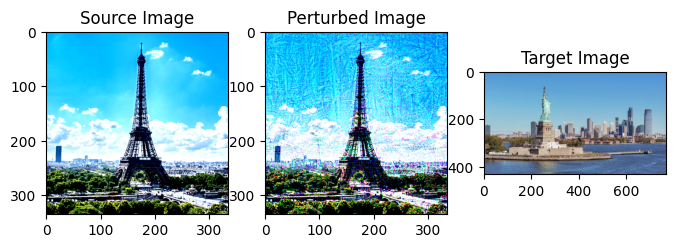

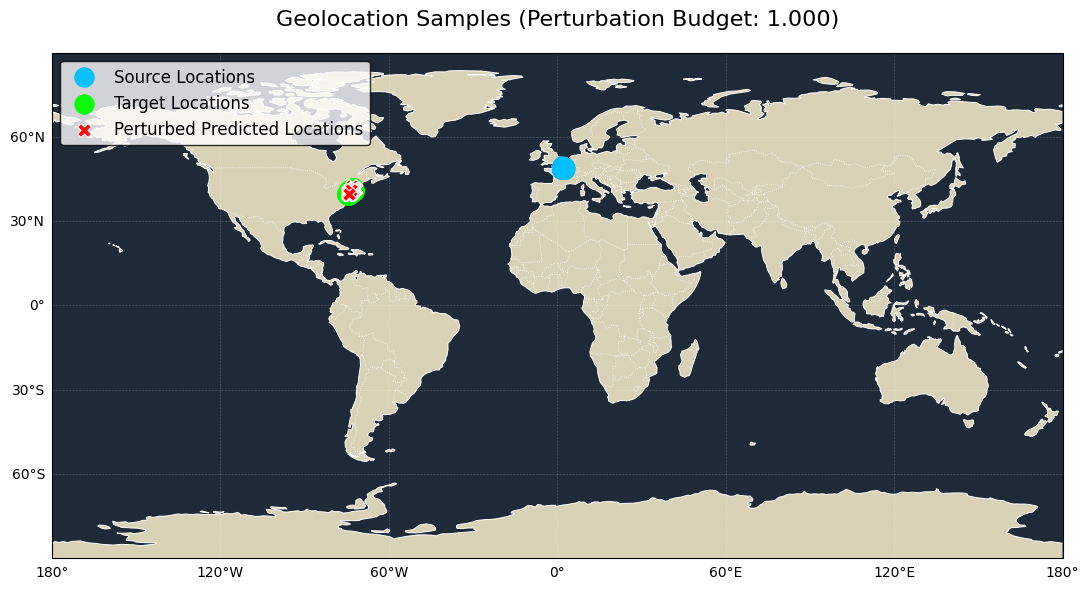

In [195]:
# Plot on a map the GPS coordinate samples for source, target, and perturbed images.

def plot_gps_samples_on_map(gps_coords_source, gps_coords_target, gps_coords_perturbed, perturb_budget = None):
    plt.figure(figsize=(12,6))
    ax = plt.axes(projection=ccrs.PlateCarree())
    ax.set_global()
    ax.set_extent([-180, 180, -90, 90], crs=ccrs.PlateCarree())

    # Higher-contrast map colors for better point visibility
    ax.set_facecolor('#1f2a38')
    ax.add_feature(cfeature.OCEAN, facecolor='#1f2a38')
    ax.add_feature(cfeature.LAND, facecolor='#d9d2b6', edgecolor='none')
    ax.add_feature(cfeature.COASTLINE, edgecolor='white', linewidth=0.7)
    ax.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='white', linewidth=0.6)

    # Pipeline outputs arrays shaped [N, 2] as [latitude, longitude]
    ax.scatter(
        gps_coords_source[:, 1],
        gps_coords_source[:, 0],
        color='deepskyblue',
        marker='o',
        s=200,
        alpha=0.95,
        linewidths=0.5,
        transform=ccrs.PlateCarree(),
        label='Source Locations',
        zorder=5,
    )

    ax.scatter(
        gps_coords_target[:, 1],
        gps_coords_target[:, 0],
        color='lime',
        marker='o',
        s=200,
        alpha=0.95,
        linewidths=0.5,
        transform=ccrs.PlateCarree(),
        label='Target Locations',
        zorder=6,
    )
    ax.scatter(
        gps_coords_perturbed[:, 1],
        gps_coords_perturbed[:, 0],
        color='red',
        marker='X',
        s=100,
        alpha=0.95,
        edgecolors='white',
        linewidths=0.8,
        transform=ccrs.PlateCarree(),
        label='Perturbed Predicted Locations',
        zorder=7,
    )

    # Add gridlines
    gl = ax.gridlines(draw_labels=True, linewidth=0.45, color='white', alpha=0.25, linestyle='--')
    gl.top_labels = False
    gl.right_labels = False

    # Add title and legend
    title = 'Geolocation Samples (Global View)' if perturb_budget is None else f'Geolocation Samples (Perturbation Budget: {perturb_budget:.3f})'
    plt.title(title, fontsize=16, color='black', pad=20)
    plt.legend(loc='upper left', fontsize='large', frameon=True, facecolor='white', edgecolor='black')

    plt.tight_layout()
    plt.show()
    

#plot all 3 images:
source_tensor = pipeline.cond_preprocessing.augmentation(source_image).unsqueeze(0).to(device)
source_image_reformatted = tensor_to_pil(source_tensor.squeeze(0))
fig, axs = plt.subplots(1, 3, figsize=(8, 5))
axs[0].imshow(source_image_reformatted)
axs[0].set_title("Source Image")
axs[1].imshow(pertubed_image)
axs[1].set_title("Perturbed Image")
axs[2].imshow(target_image)
axs[2].set_title("Target Image")
plt.show()    

plot_gps_samples_on_map(gps_coords_source, gps_coords_target, gps_coords_perturbed, perturb_budget=attack_size)

##### Second run, composite loss
Does not work very well for $\lambda_x \sim 0.5$ or higher. 

In [192]:
device ="cuda" if torch.cuda.is_available() else "cpu"

num_steps=200
attack_size = 1
step_size=0.1

l_x=0.8
l_z=1.0

delta = train_perturbation(source_image, z_target, pipeline,num_steps=num_steps,step_size=step_size, device=device, attack_size=attack_size, criterion_name="MSE+Reconstruction", l_z=l_z, l_x=l_x)

pertubed_image_2 = add_perturbation_to_image(source_image, delta)

Training Perturbation:   0%|          | 0/200 [00:00<?, ?it/s]

Training Perturbation: 100%|██████████| 200/200 [00:24<00:00,  8.12it/s, loss=0.037932, loss_z=0.005045, loss_x=0.041109]


In [196]:
gps_coords_perturbed_2 = pipeline(pertubed_image_2, batch_size=1024, cfg=2.0)

/Data/mathias.ollu/plonk/plonk/models/samplers/ddim.py:31: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(dtype=dtype):


In [181]:
gps_coords_source_2 = pipeline(source_image, batch_size=1024, cfg=2.0)
gps_coords_target_2 = pipeline(target_image, batch_size=1024, cfg=2.0)

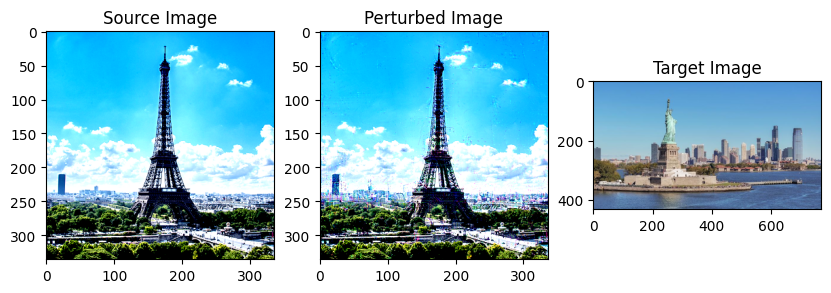

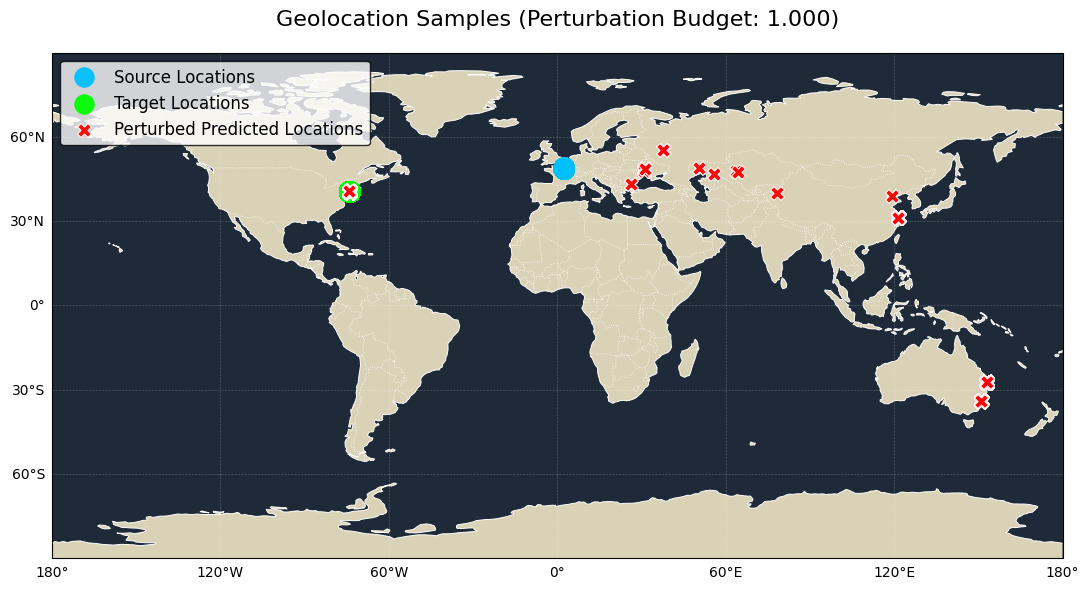

In [197]:
#plot all 3 images:
fig, axs = plt.subplots(1, 3, figsize=(10, 8))
source_tensor = pipeline.cond_preprocessing.augmentation(source_image).unsqueeze(0).to(device)
source_image_reformatted = tensor_to_pil(source_tensor.squeeze(0))
axs[0].imshow(source_image_reformatted)
axs[0].set_title("Source Image")
axs[1].imshow(pertubed_image_2)
axs[1].set_title("Perturbed Image")
axs[2].imshow(target_image)
axs[2].set_title("Target Image")
plt.show()
plot_gps_samples_on_map(gps_coords_source_2, gps_coords_target_2, gps_coords_perturbed_2, perturb_budget=attack_size)
